<a href="https://colab.research.google.com/github/LleilaA13/Thesis-MUL/blob/random-data-forgetting/notebooks/10_random_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### This notebook uses the Lucent library, which is licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Feature visualization: Pre vs. Post Machine Unlearning
This notebook demonstrates how machine unlearning affects the internal representations of neural networks by visualizing learned features before and after the unlearning process. We employ the **Lucent** library to generate feature visualizations and compare activation patterns across different layers of the network.

**Feature visualization:**
Generally speaking, neural networks are differentiable with respect to their inputs, meaning that certain inputs cause a certain behaviour.

Starting with random noise, we optimize an image to activate a particular neuron.



**How Lucent works:**
The core idea is to optimize the input image to the network such that a certain neuron or channel gets maximally excited.


**Random Forgetting with SalUn: Resnet-50 on Tiny ImageNet:**

We randomly select and forget **10% of the training data** and provide a comprehensive analysis of how unlearning affects different model components.


## Install, Import, Load model

In [42]:
!pip install --quiet git+https://github.com/greentfrapp/lucent.git

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import torchvision.transforms as T
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform, objectives
from lucent.optvis.render import render_vis, export, show # Import show
import pandas as pd
import json

In [ ]:
#fix seed for reproducibility
torch.manual_seed(0)

In [ ]:

def load_resnet50(path):
  model = models.resnet50(num_classes=200)
  checkpoint = torch.load(path, map_location='cpu', weights_only=False)
  try:
      model.load_state_dict(checkpoint['state_dict'], strict=False)
  except:
      model.load_state_dict(checkpoint, strict=False)
  model.eval()
  return model

In [ ]:
import os
from google.colab import drive
from IPython.display import clear_output

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/THESIS')

clear_output()

try:
    import importlib.util
    spec = importlib.util.spec_from_file_location("config", "config.py")
    config_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(config_module)
    Config = config_module.Config

    summary_path = Config.ANALYSIS_10PCT
    targets_path = Config.TARGETS_10PCT
    pretrained_model_path = Config.PRETRAINED_MODEL
    unlearned_model_path = Config.UNLEARNED_MODEL

    print("✓ Configuration loaded with relative paths")
    print(f"✓ Working from: {Config.BASE_DIR}")

except FileNotFoundError:
    print("✗ config.py not found in the current directory.")
except AttributeError:
    print("✗ 'Config' class not found in config.py.")
except Exception as e:
    print(f"An error occurred while loading config: {e}")

✓ Configuration loaded with relative paths
✓ Working from: /content/drive/MyDrive/THESIS


In [ ]:

# Load the pretrained and unlearned models
pretrained_model = load_resnet50(path=pretrained_model_path)
unlearned_model = load_resnet50(path=unlearned_model_path)

print("Pretrained model loaded successfully.")
print("Unlearned model loaded successfully.")

Pretrained model loaded successfully.
Unlearned model loaded successfully.


# Weight Analysis:

First of all, we need to show the most influenced weights, neurons, layers and channels.


After unlearning, we have made a script that runs an "influence" analysis to identify which network components were most affected by the unlearning process.

It does it by comparing the baseline model to the unlearned moded, by computing the difference between the weights of the two models at various levels:

    Layer level : measures the average changes per layers
    Channel level : measures changes per channel within layers.
    Weight level : measures changes for individual weigts.

Then it identifies and ranks the most influenced layers, channels, and weights, and finally it prepares a list of the most affected channels/layers for feature visualization


In [ ]:

# Load and Parse JSON Data
with open(summary_path, 'r') as f:
    influence_summary = json.load(f)

with open(targets_path, 'r') as f:
    lucent_targets = json.load(f)

print(" Data Loaded Successfully")
print(f"Model: {influence_summary['model_info']['architecture']}")
print(f"Total Parameters: {influence_summary['model_info']['total_parameters']:,}")
print(f"Loaded {len(lucent_targets)} visualization targets")

 Data Loaded Successfully
Model: ResNet50
Total Parameters: 23,917,832
Loaded 25 visualization targets


In [ ]:
# Extract Key Findings from Summary
top_influences = influence_summary['top_influences']
statistics = influence_summary['statistics']

print(" Most Influenced Components:")
print(f"Layer: {top_influences['most_influenced_layer']} ({top_influences['max_layer_change']:.2f}%)")
print(f"Channel: {top_influences['most_influenced_channel']} ({top_influences['max_channel_change']:.2f}%)")
print(f"Weight: {top_influences['most_influenced_weight']} ({top_influences['max_weight_change']:.0f}%)")

print("\n Analysis Statistics:")
print(f"Average layer change: {statistics['avg_layer_change']:.2f}%")
print(f"Average channel change: {statistics['avg_channel_change']:.2f}%")
print(f"Average weight change: {statistics['avg_weight_change']:.0f}%")


 Most Influenced Components:
Layer: conv1.weight (25.33%)
Channel: layer3.0.conv3.weight_ch902 (3978.55%)
Weight: layer3.5.conv2.weight_ch98_w644 (1406244%)

 Analysis Statistics:
Average layer change: 4.98%
Average channel change: 195.98%
Average weight change: 48407%


In [ ]:
# Process Lucent Targets for Visualization
# Separate channels and layers
channels = [t for t in lucent_targets if t['type'] == 'channel']
layers = [t for t in lucent_targets if t['type'] == 'layer']

print(f"Found {len(channels)} channel targets and {len(layers)} layer targets")

channels_df = pd.DataFrame(channels)
layers_df = pd.DataFrame(layers)

# Display top 15 most influenced channels
print("\n Top 15 Most Influenced Channels:")
top_channels = channels_df.nlargest(15, 'influence_score')
for _, channel in top_channels.iterrows():
    print(f"  {channel['target']} - Score: {channel['influence_score']:.2f}")


Found 15 channel targets and 10 layer targets

 Top 15 Most Influenced Channels:
  layer3.0.conv3:902 - Score: 3978.55
  layer3.0.conv3:793 - Score: 1097.44
  conv1:23 - Score: 633.71
  layer3.5.conv2:98 - Score: 613.19
  layer3.1.conv2:123 - Score: 416.79
  layer3.4.conv2:200 - Score: 262.23
  layer3.0.conv3:651 - Score: 241.59
  layer4.0.conv2:390 - Score: 186.58
  conv1:35 - Score: 161.68
  layer3.0.conv2:175 - Score: 154.62
  layer3.0.conv3:20 - Score: 128.79
  layer2.0.conv2:34 - Score: 101.61
  layer3.0.conv2:230 - Score: 96.55
  layer4.1.conv2:23 - Score: 94.96
  layer3.0.conv2:56 - Score: 87.00


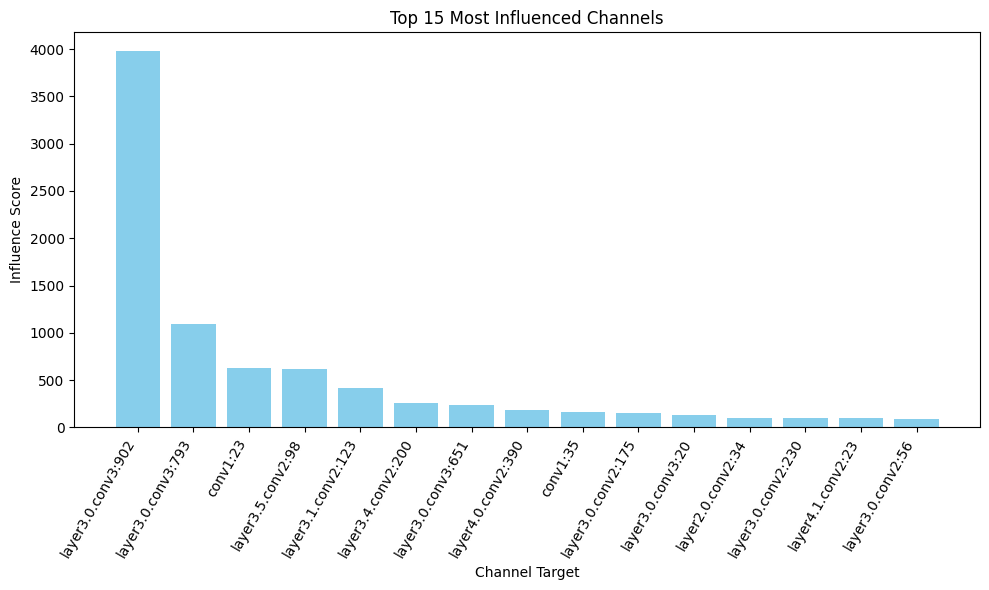

In [ ]:
import matplotlib.pyplot as plt

# Top 15 channel targets by influence score
top_channels = channels_df.nlargest(15, 'influence_score')

plt.figure(figsize=(10, 6))
plt.bar(top_channels['target'], top_channels['influence_score'], color='skyblue')
plt.xticks(rotation=60, ha='right')
plt.title("Top 15 Most Influenced Channels")
plt.xlabel("Channel Target")
plt.ylabel("Influence Score")
plt.tight_layout()
plt.show()

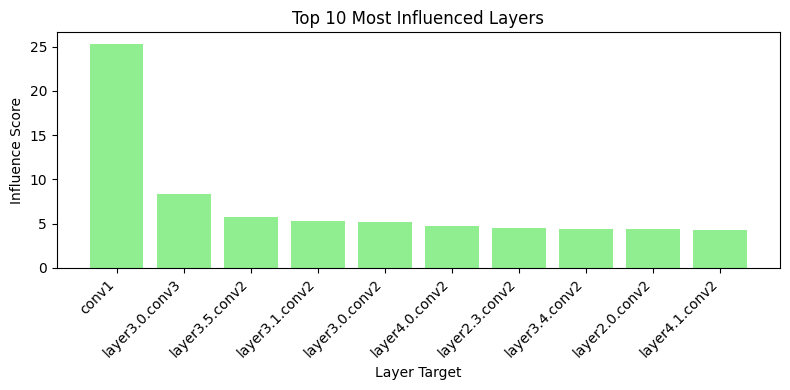

In [ ]:
# Top 10 layer targets by influence score
top_layers = layers_df.nlargest(10, 'influence_score')

plt.figure(figsize=(8, 4))
plt.bar(top_layers['target'], top_layers['influence_score'], color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Most Influenced Layers")
plt.xlabel("Layer Target")
plt.ylabel("Influence Score")
plt.tight_layout()
plt.show()


# Lucent feature visualization:
Now, we use the Lucent library to visualize these layers and channels most affected by the unlearning process.




## **Objectives:**

What loss function do we want to minimize?

Or from another point of view, what part of the model do we want to understand?

We are trying to generate an image that causes a particular neuron or filter to activate strongly.



In [ ]:
#First, let's get the name of the model layers:
print(get_model_layers(pretrained_model))

['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_0_conv3', 'layer1_0_bn3', 'layer1_0_relu', 'layer1_0_downsample', 'layer1_0_downsample_0', 'layer1_0_downsample_1', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_conv2', 'layer1_1_bn2', 'layer1_1_conv3', 'layer1_1_bn3', 'layer1_1_relu', 'layer1_2', 'layer1_2_conv1', 'layer1_2_bn1', 'layer1_2_conv2', 'layer1_2_bn2', 'layer1_2_conv3', 'layer1_2_bn3', 'layer1_2_relu', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_conv3', 'layer2_0_bn3', 'layer2_0_relu', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_conv2', 'layer2_1_bn2', 'layer2_1_conv3', 'layer2_1_bn3', 'layer2_1_relu', 'layer2_2', 'layer2_2_conv1', 'layer2_2_bn1', 'layer2_2_conv2', 'layer2_2_bn2', 'layer2_2_conv3', 'layer2_2_bn3', 'layer2_2_relu', 'layer2_3', 

100%|██████████| 512/512 [04:49<00:00,  1.77it/s]



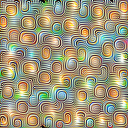

100%|██████████| 512/512 [04:38<00:00,  1.84it/s]



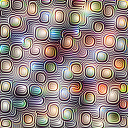

In [ ]:
# The default is optimizing for a channel/filter
#let's choose layer3.0.conv2:175 - Score: 154.62. In lucent it's "layer3_0_conv2"
target_layer = "layer3_0_conv2"
target_channel = 175
obj = objectives.channel(target_layer, target_channel)
image_before = render.render_vis(pretrained_model, obj, show_inline=True)
image_after = render.render_vis(unlearned_model, obj, show_inline=True)

100%|██████████| 256/256 [02:29<00:00,  1.71it/s]



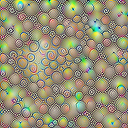

100%|██████████| 256/256 [02:32<00:00,  1.68it/s]



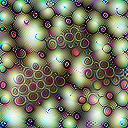

In [ ]:
# layer3.0.conv3:902
obj = objectives.channel("layer3_0_conv3", 902)

image_original = render.render_vis(pretrained_model, obj, thresholds=(256,), show_inline=True)
image_unlearned = render.render_vis(unlearned_model, obj, thresholds=(256,), show_inline=True)


## **Parameterizations and Transformations:**
Parameterization works by operating in the frequency domain or using compositional pattern producing networks.
Another way to reduce high-frequency components in the visualization is by imposing constraints in the form of transformation robustness.

Those transformations could be paddings, small translations (jitter), rescaling and rotating, just to name a few.

In [ ]:
obj = objectives.channel("layer3_0_conv3", 902)

In [ ]:
#default setting for render_vis:
standard_transforms = [
    transform.pad(12, mode="constant", constant_value=0.5),
    transform.jitter(8),
    transform.random_scale([1 + (i - 5) / 50.0 for i in range(11)]),
    transform.random_rotate(list(range(-10, 11)) + 5 * [0]),
    transform.jitter(4),
]

100%|██████████| 512/512 [04:38<00:00,  1.84it/s]



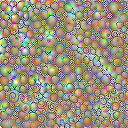

100%|██████████| 512/512 [04:37<00:00,  1.84it/s]



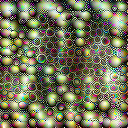

In [ ]:
#Example with no transformations (the ones above had transformations, default in render_vis):
_ = render.render_vis(pretrained_model, "layer3_0_conv3:902", transforms=[], show_inline=True)
_ = render.render_vis(unlearned_model, "layer3_0_conv3:902", transforms=[], show_inline=True)

100%|██████████| 512/512 [04:40<00:00,  1.82it/s]



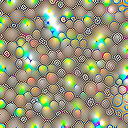

100%|██████████| 512/512 [04:43<00:00,  1.81it/s]



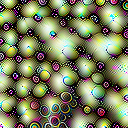

In [ ]:
# Adding a whole suite of transforms
all_transforms = [
    transform.pad(16),
    transform.jitter(8),
    transform.random_scale([n/100. for n in range(80, 120)]),
    transform.random_rotate(list(range(-10,10)) + list(range(-5,5)) + 10*list(range(-2,2))),
    transform.jitter(2),
]

_ = render.render_vis(pretrained_model, obj, transforms=all_transforms, show_inline=True)
_ = render.render_vis(unlearned_model, obj, transforms=all_transforms, show_inline=True)


# Batching:

Let's say you want to generate many visualizations at once, either for different settings and the same objective or different objectives.

The way Lucent handles this is a bit unintuitive in the beginning.

In essence, you can specify for each objective function which batch dimension it should pay attention to. By default, an objective is applied to the full batch of images, but you can also pass a batch parameter to specify which element of the batch it should be applied to. (Anything in between one element and all elements is not support at the moment.)

So.. what does this mean for our parameterization function? We have to make sure that the returned images also have a batch dimension. If you are using the built-in parameterizations, you can simply pass this as an additional parameter:

In [ ]:
batch_size = 3
param_f = lambda: param.image(w=128, batch=batch_size) #This creates a single tensor containing three separate, noisy images.


Now, let's say we want to optimize three different channels, 902, 793, and 651 of the layer layer3_0_conv0. It is not a random choice, those are some of the most influenced channels in layer "layer3.0.conv0". We do this by creating the sum of the individual objectives and setting the batch keyword argument to a different value in [0,1,2] for each of them. This way, each objective will only be applied to the i-th image, and we can optimize them in parallel.

The entire batch of 3 images is passed through the model.

The objective function calculates the loss. Because of how you defined it:

    The loss for the first image is calculated based on how much it activated channel 902.

    The loss for the second image is calculated based on how much it activated channel 793.

    The loss for the third image is calculated based on how much it activated channel 651.

The optimizer updates the pixels of all three images in parallel, but the updates for each image are based only on its own specific goal.

The result is that the three images evolve independently, each one optimized to visualize a different channel. When the process is finished, render_vis returns the batch of three fully-optimized images as a list.

100%|██████████| 512/512 [13:00<00:00,  1.52s/it]



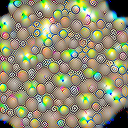
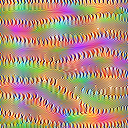
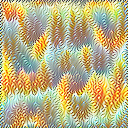

100%|██████████| 512/512 [13:35<00:00,  1.59s/it]



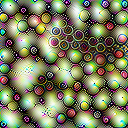
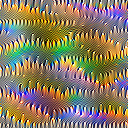
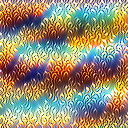

In [ ]:
objective = objectives.Objective.sum([objectives.channel('layer3_0_conv3', ch, batch=i) for i, ch in enumerate([902, 793, 651])])
images_pretrained = render.render_vis(pretrained_model, objective, param_f=param_f, show_inline=True) # list_of_images has length 3
images_unlearned = render.render_vis(unlearned_model, objective, param_f=param_f, show_inline=True) # list_of_images has length 3

# Diversity:
Encourage diversity between each batch element. A neural network feature often responds to multiple things, but naive feature visualization often shows us one. If we optimize a batch of "images", this objective will encourage them to be different.

In particular, it calculates the correlation matrix of activations at layer for each image, and then penalizes cosine similarity between them.


```
 Args: layer:  layer to evaluate activation correlations on.
 Returns: Objective
```



With the diversity objective, we have to submit a batch of images for optimization. The diversity objective then tries to maximize the difference in feature representations between the images in the batch.

This code generates four different visualizations of the same channel by simultaneously encouraging activation and forcing the images to be visually distinct from one another.

It's a powerful technique to explore the different "facets" or sub-concepts that a single neuron has learned.

This objective sets up two competing goals for the optimizer:

 - objectives.channel("layer3_0_conv3", 793): The primary goal. It tells the optimizer to change the images to maximally activate channel 793 in the "layer3_0_conv3" layer.

  - 1e3 * objectives.diversity(...): The "twist." The diversity objective calculates how similar the images in the batch are to each other (at the "layer3_0_conv3" layer). By subtracting a large amount (1e3 = 1000) of this term, you are creating a strong penalty for similarity. The optimizer will actively try to make the images look different from each other to minimize this penalty.

When render.render_vis runs, it tries to satisfy the combined objective for the batch of four images. The result is that all four images will strongly activate channel 793, but they will be forced to find different ways to do so.

100%|██████████| 256/256 [10:22<00:00,  2.43s/it]



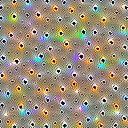
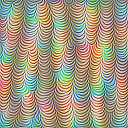
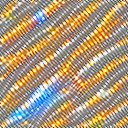
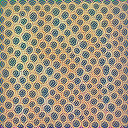

100%|██████████| 256/256 [10:25<00:00,  2.44s/it]



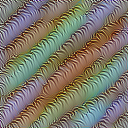
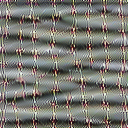
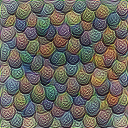
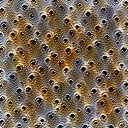

In [ ]:
batch_param_f = lambda: param.image(128, batch=4)
obj = objectives.channel("layer3_0_conv3", 793) - 1e3 * objectives.diversity("layer3_0_conv3")

_ = render.render_vis(pretrained_model, obj, batch_param_f, thresholds=(256,), show_inline=True)
_ = render.render_vis(unlearned_model, obj, batch_param_f, thresholds=(256,), show_inline=True)

# Negative channel visualizations
We can generate visualizations that maximize activations in both the positive and negative directions.

Note that the positive term has the ``batch=1`` keyword while the negative term has the ``batch=0`` keyword. So the left image optimizes the negative term and the right image optimizes the positive term.




In [ ]:
#layer3.0.conv3:793 - Score: 1097.44
param_f = lambda: param.image(224, batch=2)
obj = objectives.channel("layer3_0_conv3", 793, batch=1) - objectives.channel("layer3_0_conv3", 793, batch=0)
_ = render.render_vis(pretrained_model, obj, param_f, thresholds=(256,), show_inline=True)

  4%|▍         | 11/256 [00:14<05:27,  1.34s/it]

Let's try a new thing: creating an image of a concept suppressed during unlearning. Since we do not have the exact data that has been removed, the best approach is to use the original model's own feature visualization as the proxy. This creates a powerful, self-referential analysis of what has changed.





1.  **Generate a "Perfect" Image:** First, it asks the original, fully-trained model to create an image of what a specific channel is looking for. This becomes the "proxy image" that represents the concept we're investigating.

2.  **Measure the "Before" and "After" Reaction:** It then shows this proxy image to both the original model and the unlearned model, recording how strongly the target layer reacts in each case.

3.  **Calculate the Difference:** It subtracts the unlearned model's weak reaction from the original model's strong reaction. This difference, the `activation_delta`, is a numerical representation of the "scar" or "ghost" of the forgotten knowledge.

4.  **Visualize the "Scar":** Finally, it uses another visualization technique (`objectives.direction`) to turn this numerical difference back into an image. The final picture you see is a visualization of the specific pattern the unlearned model has been taught to ignore, effectively showing you the concept that was removed.

Generating proxy image for 'layer3_0_conv3:902'...


100%|██████████| 256/256 [02:33<00:00,  1.67it/s]


Proxy image tensor created with correct shape: torch.Size([1, 3, 128, 128])
Capturing activations from both models...
Calculated 4D activation delta with shape: torch.Size([1, 1024, 8, 8])
Collapsed delta into 1D direction vector with shape: torch.Size([1024])
Visualizing the functional 'scar' for layer 'layer3_0_conv3'...


100%|██████████| 512/512 [05:22<00:00,  1.59it/s]


Visualization of the 'Unlearned Concept' (The Scar):



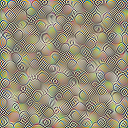

In [43]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
def get_activations(model, layer_name, image_tensor):
    """A hook-based function to grab layer activations."""
    activations = {}
    def hook_fn(module, input, output):
        activations['value'] = output

    # Convert Lucent's underscore notation to PyTorch's dot notation to find the module
    module_name_dot = layer_name.replace('_', '.')
    target_module = dict(model.named_modules())[module_name_dot]

    handle = target_module.register_forward_hook(hook_fn)
    model(image_tensor)
    handle.remove() # Clean up the hook
    return activations['value']


# --- 1. Define Your Target ---
#layer3.0.conv3:902
target_layer = 'layer3_0_conv3'
target_channel = 902 #

# --- 2. Generate the "Ideal" Proxy Image ---
# First, we create a standard feature visualization from the original model.
# This image will serve as our stand-in for the forgotten data.
objective = objectives.channel(target_layer, target_channel)

print(f"Generating proxy image for '{target_layer}:{target_channel}'...")
# We get the raw NumPy array back by setting show_image=False
proxy_image_numpy_list = render.render_vis(pretrained_model, objective, thresholds=(256,), progress=True, show_image=False)

# --- 3. CORRECTED PART: Convert NumPy output to the correct PyTorch tensor format ---
# render_vis returns a list containing a NumPy array of shape (Batch, Height, Width, Channels)
proxy_image_numpy = proxy_image_numpy_list[0]

# Convert it to a PyTorch tensor and permute from BHWC to the required BCHW format
# This is the critical fix for the previous RuntimeError.
proxy_image_tensor = torch.from_numpy(proxy_image_numpy).permute(0, 3, 1, 2).float().to(device)
print(f"Proxy image tensor created with correct shape: {proxy_image_tensor.shape}")
# --- 4. Calculate the "Activation Delta" Using the Proxy Image ---
# Now, use this correctly formatted tensor as input to get the "before" and "after" activations.
print("Capturing activations from both models...")
activs_before = get_activations(pretrained_model, target_layer, proxy_image_tensor)
activs_after = get_activations(unlearned_model, target_layer, proxy_image_tensor)

# This difference is a 4D tensor (Batch, Channels, Height, Width).
activation_delta = activs_before - activs_after
print(f"Calculated 4D activation delta with shape: {activation_delta.shape}")

# --- 5. CORRECTED PART: Collapse the scar into a 1D direction vector ---
# We take the mean across the spatial dimensions (Height and Width) to get the average
# change in the channel space. This is the vector the `direction` objective expects.
direction_vector = torch.mean(activation_delta, dim=[2, 3]).squeeze().detach()
print(f"Collapsed delta into 1D direction vector with shape: {direction_vector.shape}")


scar_objective = objectives.direction(target_layer, direction_vector)

print(f"Visualizing the functional 'scar' for layer '{target_layer}'...")
images_scar = render.render_vis(pretrained_model, scar_objective, progress=True, show_image=False)

# --- 7. Display the final result ---
print("\nVisualization of the 'Unlearned Concept' (The Scar):")
show(images_scar[0])